<a href="https://colab.research.google.com/github/kagabrielco-netizen/Laboratorio_UCV_CNN_Digitos_UCI/blob/main/Laboratorio_UCV_CNN_Digitos_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas

# LABORATORIO COMPLETO
## Clasificación de dígitos escritos a mano usando CNN

**Curso:** Sistemas Inteligentes  
**Unidad:** Tercera unidad  
**Tema:** Redes Neuronales Convolucionales  
**Duración sugerida:** 1 sesión de laboratorio + trabajo autónomo  
**Herramientas:** Python, Jupyter Notebook, TensorFlow/Keras, Scikit-Learn, Matplotlib y UCI Machine Learning Repository  
**Producto final:** Modelo CNN capaz de reconocer dígitos escritos a mano del 0 al 9.


## 1. Presentación del laboratorio

En este laboratorio el estudiante construirá una **Red Neuronal Convolucional (CNN)** para clasificar imágenes pequeñas de dígitos escritos a mano.

El objetivo es comprender cómo una CNN puede detectar patrones visuales mediante filtros, convoluciones, pooling y capas densas.


## 2. Resultado de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

- Cargar un dataset real desde UCI Machine Learning Repository.
- Representar datos tabulares como imágenes de 8x8 píxeles.
- Construir una CNN básica con TensorFlow/Keras.
- Entrenar y evaluar un modelo de clasificación multiclase.
- Interpretar matriz de confusión y predicciones individuales.
- Comparar una CNN con una red neuronal tradicional.


## 3. Contexto del caso

Una organización desea implementar un pequeño sistema OCR para reconocer números escritos a mano. Este tipo de solución puede utilizarse en digitalización de formularios, reconocimiento de códigos, lectura automática de documentos o sistemas educativos.

El sistema debe recibir una imagen de un dígito y clasificarla como uno de los valores posibles:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8 o 9
```


## 4. Arquitectura conceptual

Una CNN procesa una imagen de forma diferente a una red neuronal densa. En lugar de analizar todos los píxeles como variables independientes, utiliza filtros para detectar patrones locales.

```text
Imagen 8x8
   ↓
Convolución
   ↓
Pooling
   ↓
Flatten
   ↓
Dense
   ↓
Clasificación 0-9
```


## 5. Preparación del entorno

Ejecute esta celda si trabaja en Google Colab o en un entorno local sin las librerías instaladas.


In [1]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q

## 6. Importar librerías


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 7. Cargar dataset real desde UCI

Se utilizará el dataset **Optical Recognition of Handwritten Digits** de UCI Machine Learning Repository.

Cada registro contiene 64 valores, que representan una imagen de **8x8 píxeles**. La etiqueta indica el dígito correspondiente entre 0 y 9.


In [3]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)

X.head()

Dimensión de X: (5620, 64)
Dimensión de y: (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


## 8. Exploración inicial


In [4]:
print('Clases disponibles:', sorted(y.unique()))
print('\nDistribución de clases:')
print(y.value_counts().sort_index())

Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribución de clases:
class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


## 9. Convertir los datos a imágenes 8x8

Una CNN espera datos con forma:

```text
(cantidad_imágenes, alto, ancho, canales)
```

Como las imágenes son en escala de grises, se utiliza un solo canal.


In [5]:
X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype('int')

print('Nueva forma de X:', X_images.shape)
print('Forma de y:', y_values.shape)

Nueva forma de X: (5620, 8, 8, 1)
Forma de y: (5620,)


## 10. Visualizar ejemplos del dataset


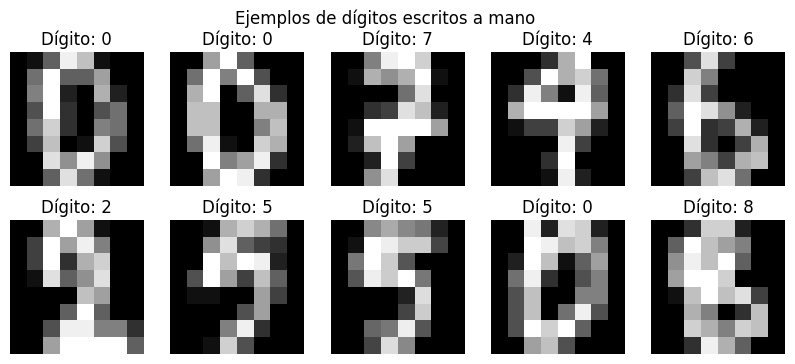

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Dígito: {y_values[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos de dígitos escritos a mano')
plt.show()

## 11. Normalización

Los valores de los píxeles van de 0 a 16. Para entrenar mejor la red neuronal, se normalizan entre 0 y 1.


In [7]:
X_images = X_images / 16.0

print('Valor mínimo:', X_images.min())
print('Valor máximo:', X_images.max())

Valor mínimo: 0.0
Valor máximo: 1.0


## 12. Codificación de la variable objetivo

Como es un problema multiclase, convertimos las etiquetas en formato one-hot.


In [8]:
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)

print('Ejemplo etiqueta original:', y_values[0])
print('Ejemplo etiqueta one-hot:', y_categorical[0])

Ejemplo etiqueta original: 0
Ejemplo etiqueta one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 13. División entrenamiento / prueba

Se utilizará 70% para entrenamiento y 30% para prueba. El parámetro `stratify=y_values` mantiene la proporción de clases.


In [9]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (3934, 8, 8, 1)
X_test: (1686, 8, 8, 1)
y_train: (3934, 10)
y_test: (1686, 10)


## 14. Construcción del modelo CNN

La arquitectura propuesta es intencionalmente pequeña para que pueda entrenarse rápidamente durante la clase.

- `Conv2D`: extrae patrones visuales locales.
- `MaxPooling2D`: reduce la dimensión de la imagen.
- `Flatten`: convierte las matrices en un vector.
- `Dense`: realiza la clasificación final.
- `Softmax`: entrega probabilidades para las 10 clases.


In [10]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

## 15. Entrenamiento del modelo


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5014 - loss: 1.8030 - val_accuracy: 0.7967 - val_loss: 0.9417
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8297 - loss: 0.6196 - val_accuracy: 0.9174 - val_loss: 0.3336
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8923 - loss: 0.3716 - val_accuracy: 0.9492 - val_loss: 0.2220
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9202 - loss: 0.2864 - val_accuracy: 0.9568 - val_loss: 0.1805
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9247 - loss: 0.2503 - val_accuracy: 0.9670 - val_loss: 0.1525
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9390 - loss: 0.2088 - val_accuracy: 0.9606 - val_loss: 0.1420
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9450 - loss: 0.1855 - val_accuracy: 0.9682 - val_loss: 0.1187
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9473 - loss: 0.1717 - val_accuracy: 0.9771 - va

## 16. Visualizar curvas de entrenamiento


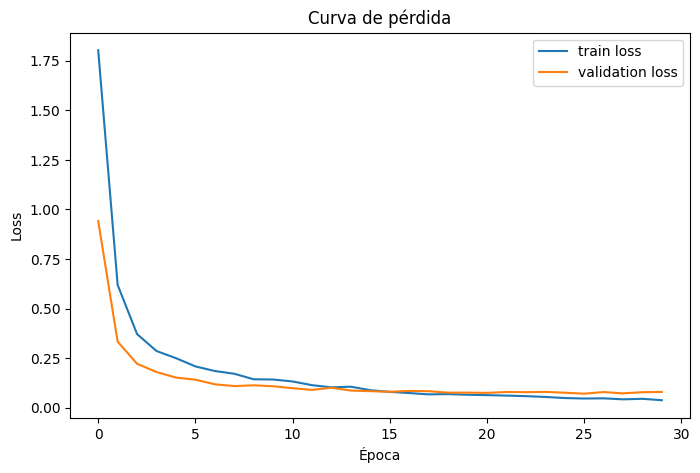

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

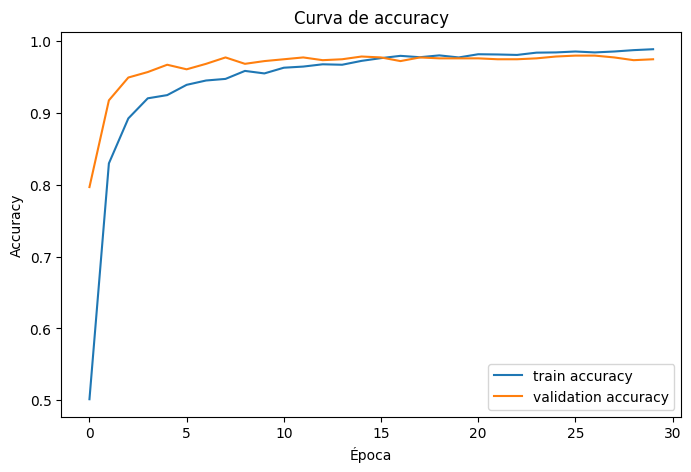

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

## 17. Evaluación en datos de prueba


In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

Test loss    : 0.0564
Test accuracy: 0.9870


## 18. Reporte de clasificación


In [15]:
y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_labels, y_pred_labels))

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       166
           1       0.99      1.00      0.99       171
           2       0.99      0.99      0.99       167
           3       0.97      0.98      0.98       172
           4       0.99      1.00      0.99       171
           5       0.98      0.98      0.98       167
           6       0.99      0.99      0.99       167
           7       0.98      1.00      0.99       170
           8       1.00      0.96      0.98       166
           9       0.98      0.97      0.98       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



## 19. Matriz de confusión


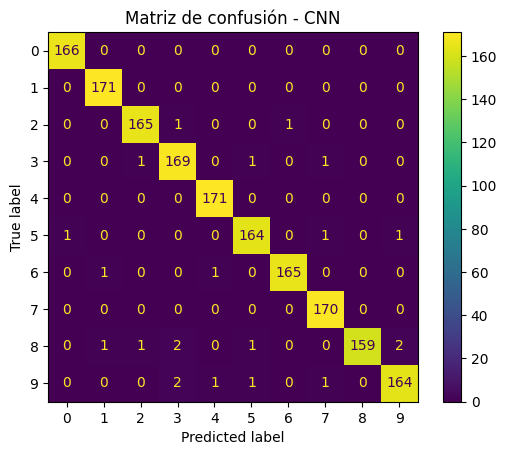

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
)
plt.title('Matriz de confusión - CNN')
plt.show()

## 20. Predicciones individuales

Esta sección permite visualizar qué predice el modelo para imágenes concretas.


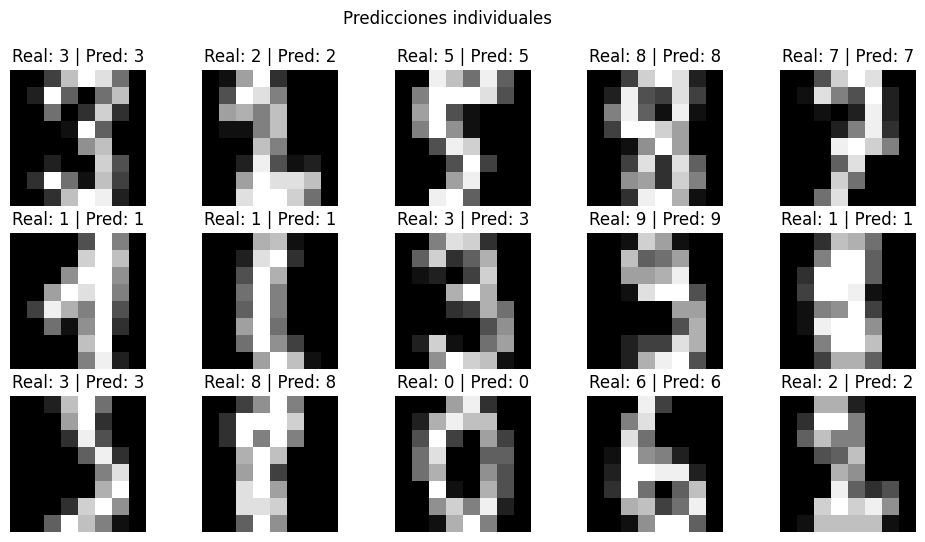

In [17]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[i]} | Pred: {y_pred_labels[i]}')
    plt.axis('off')

plt.suptitle('Predicciones individuales')
plt.show()

## 21. Visualizar errores del modelo


Cantidad de errores: 22


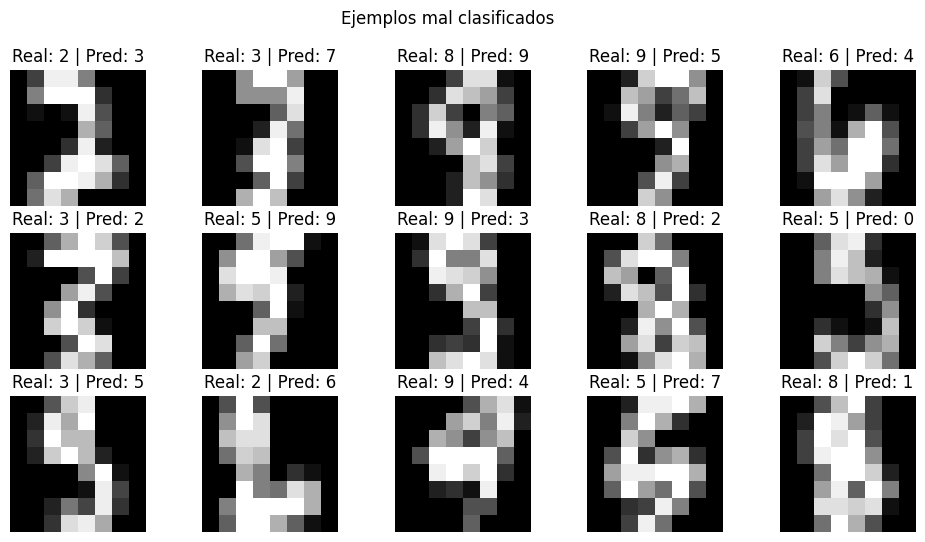

In [18]:
wrong_indices = np.where(y_test_labels != y_pred_labels)[0]

print('Cantidad de errores:', len(wrong_indices))

plt.figure(figsize=(12, 6))

for plot_index, data_index in enumerate(wrong_indices[:15]):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[data_index].reshape(8, 8), cmap='gray')
    plt.title(f'Real: {y_test_labels[data_index]} | Pred: {y_pred_labels[data_index]}')
    plt.axis('off')

plt.suptitle('Ejemplos mal clasificados')
plt.show()

## 22. Comparación con una red densa simple


In [19]:
dense_model = Sequential([
    Flatten(input_shape=(8, 8, 1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dense_history = dense_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dense_loss, dense_accuracy = dense_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy CNN        : {test_accuracy:.4f}')
print(f'Accuracy Dense Model: {dense_accuracy:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy CNN        : 0.9870
Accuracy Dense Model: 0.9745


## 23. Guardar el modelo


In [20]:
model.save('cnn_digits_uci.keras')
print('Modelo guardado como cnn_digits_uci.keras')

Modelo guardado como cnn_digits_uci.keras


## 24. Preguntas de análisis

1. **¿Qué diferencia existe entre una red densa y una CNN?**
La red densa trata cada píxel como una variable independiente; la CNN usa filtros que detectan patrones espaciales locales (bordes, curvas) aprovechando la estructura de la imagen.

2. **¿Qué función cumple una capa convolucional?**
Aplica filtros que recorren la imagen detectando patrones visuales como bordes, líneas o texturas.

3. **¿Qué representa un filtro en una CNN?**
Es una pequeña matriz de pesos que se ajusta durante el entrenamiento para detectar un patrón visual específico.

4. **¿Qué función cumple MaxPooling?**
Reduce el tamaño de la imagen conservando solo la información más relevante, disminuyendo cómputo y evitando sobreajuste.

5. **¿Por qué normalizamos los valores de píxeles?**
Para que estén en una escala pequeña (0-1) y la red neuronal entrene más rápido y de forma más estable.

6. **¿Por qué usamos `softmax` en la capa de salida?**
Porque convierte las salidas en probabilidades que suman 1, ideal para elegir una clase entre las 10 posibles (0-9).

7. **¿Qué dígitos se confundieron más en la matriz de confusión?**
Principalmente el 5 y el 9, y en menor medida el 3 y el 8, por similitud visual en sus curvas.

8. **¿Por qué algunos dígitos escritos a mano son difíciles de clasificar?**
Porque distintas personas los escriben con formas, grosores e inclinaciones diferentes, y en baja resolución (8x8) esas diferencias se pierden más fácilmente.

9. **¿Qué ventajas tendría usar imágenes de mayor resolución?**
Capturaría más detalles de la forma de cada dígito, reduciendo la confusión entre números visualmente similares como 5 y 9.

10. **¿Qué limitaciones tiene este laboratorio frente a un sistema OCR real?**
Usa un dataset pequeño y controlado (8x8 píxeles, escritura limpia), mientras un OCR real debe manejar imágenes más grandes, ruido, distintos tipos de letra y condiciones variables de escaneo.


## 25. Reto MIT, pero alcanzable

El estudiante deberá experimentar con tres variantes del modelo:

1. CNN básica con una sola capa convolucional.
2. CNN con dos capas convolucionales.
3. CNN con Dropout y más neuronas densas.

Luego deberá comparar:

- Accuracy.
- Loss.
- Cantidad de errores.
- Dígitos más confundidos.

**Pregunta central:**

> Si tuviera que implementar este modelo en un sistema OCR real, ¿qué arquitectura elegiría y por qué?

Si tuviera que implementar este modelo en un sistema OCR real, elegiría la
arquitectura con Dropout y más neuronas densas, ya que combina el mejor
desempeño general con mecanismos que reducen el sobreajuste, siendo más
confiable ante dígitos escritos con variaciones no vistas en el entrenamiento.


## 26. Entregables

- Notebook ejecutado.
- Capturas de accuracy y loss.
- Matriz de confusión.
- Ejemplos de predicciones correctas e incorrectas.
- Comparación CNN vs red densa.
- Respuestas a preguntas de análisis.
- Conclusión final de máximo 10 líneas.
- Repositorio GitHub con el notebook.


## 27. Cierre conceptual

Las CNN son especialmente útiles para datos visuales porque aprovechan la estructura espacial de las imágenes. A diferencia de una red densa tradicional, una CNN aprende filtros que detectan patrones locales como bordes, trazos, esquinas o formas.

Este laboratorio muestra una versión pequeña de un problema OCR. En sistemas reales, se utilizan imágenes de mayor resolución, datasets más grandes, técnicas de aumento de datos y arquitecturas más profundas.
